# TP — Prédire avec ses voisins

## 🎯 Mission

Vous allez découvrir votre premier algorithme de **classification** : l'algorithme des **K plus proches voisins**, ou **K-Nearest Neighbors (KNN)**.

Votre mission sera de construire un modèle capable de classer de nouvelles observations en fonction de leur proximité avec des observations déjà connues.

À la fin du TP, vous serez capables de :

- distinguer un problème de classification d'un problème de régression ;
- comprendre intuitivement le fonctionnement de KNN ;
- utiliser `scikit-learn` pour entraîner un classifieur ;
- comprendre le rôle du paramètre `k` ;
- séparer les données d'entraînement et de test ;
- comprendre pourquoi la normalisation est importante pour KNN ;
- évaluer simplement un modèle de classification ;
- identifier les limites de l'accuracy lorsque les classes sont déséquilibrées.

---

## 🧰 Environnement

Nous utiliserons principalement :

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

et les outils de `scikit-learn` nécessaires à la classification.

---

# Partie 1 — Classification ou régression ?

Vous avez déjà rencontré la **régression linéaire**.

La régression cherche à prédire une **valeur numérique**.

Exemples :

- prédire la température de demain ;
- prédire la consommation électrique ;
- prédire le prix d'un logement.

La classification répond à une autre question :

> **À quelle catégorie appartient cette observation ?**

Exemples :

- un email est-il un spam ?
- un client va-t-il souscrire une assurance ?
- une zone est-elle susceptible d'être exposée à un risque donné ?

## 🟢 Niveau 1 — Guidé

Indiquez si les problèmes suivants sont plutôt des problèmes de **régression** ou de **classification**.

| Problème                                               | Régression ou classification ? |
| ------------------------------------------------------ | ------------------------------ |
| Prédire le prix d'une maison                           |                                |
| Prédire si un client va acheter un produit             |                                |
| Prédire la consommation d'énergie d'un bâtiment        |                                |
| Déterminer si une image contient une forêt             |                                |
| Prévoir le nombre de véhicules circulant sur une route |                                |

### Question

Quelle est, selon vous, la différence fondamentale entre la régression et la classification ?

**Réponse :**

> À compléter.

---

## 🟠 Niveau 2 — Réflexion

Imaginez un service du Ministère de la Transition écologique.

Proposez **deux problèmes métier** qui pourraient être traités par classification.

Pour chacun, précisez :

1. ce que l'on cherche à prédire ;
2. les différentes classes possibles ;
3. quelques informations qui pourraient être utilisées par le modèle.

---

## 🔴 Niveau 3 — Challenge

Imaginez que vous devez expliquer à un responsable métier la différence entre :

> « prédire une quantité »

et

> « prédire une catégorie ».

Expliquez cette différence en **trois phrases maximum**, sans utiliser de vocabulaire technique.

---

# Partie 2 — Découvrir KNN sans coder

Nous allons commencer par un jeu de données très simple.

Chaque observation possède deux caractéristiques :

- la concentration en particules fines ;
- le niveau sonore.

Nous cherchons à déterminer si une mesure correspond plutôt à une zone **résidentielle** ou **urbaine**.

Commençons par créer quelques observations.

In [1]:
import pandas as pd

data = pd.DataFrame({
    'particules_fines': [12, 15, 18, 20, 22, 48, 52, 55, 58, 62],
    'niveau_sonore': [35, 38, 42, 40, 45, 68, 72, 70, 75, 78],
    'zone': [
        'Résidentielle',
        'Résidentielle',
        'Résidentielle',
        'Résidentielle',
        'Résidentielle',
        'Urbaine',
        'Urbaine',
        'Urbaine',
        'Urbaine',
        'Urbaine'
    ]
})

data

,particules_fines,niveau_sonore,zone
0,12,35,Résidentielle
1,15,38,Résidentielle
2,18,42,Résidentielle
3,20,40,Résidentielle
4,22,45,Résidentielle
5,48,68,Urbaine
6,52,72,Urbaine
7,55,70,Urbaine
8,58,75,Urbaine
9,62,78,Urbaine


Visualisons les observations.

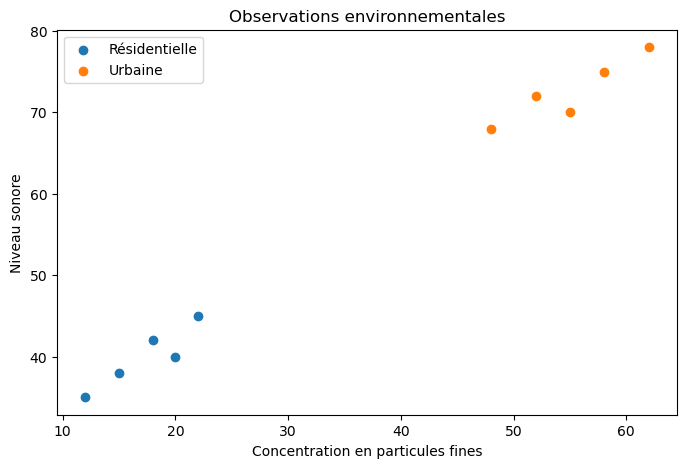

In [4]:
plt.figure(figsize=(8, 5))

for zone in data['zone'].unique():
    subset = data[data['zone'] == zone]
    plt.scatter(
        subset['particules_fines'],
        subset['niveau_sonore'],
        label=zone
    )

plt.xlabel('Concentration en particules fines')
plt.ylabel('Niveau sonore')
plt.title('Observations environnementales')
plt.legend()
plt.show()

## Question

Une nouvelle mesure possède les caractéristiques suivantes :

```text
particules_fines = 25
niveau_sonore = 48
```

À quelle catégorie pensez-vous qu'elle appartient ?

Ne codez rien pour l'instant.

**Votre réponse :**

> À compléter.

---

# Partie 3 — L'idée des plus proches voisins

L'idée de KNN est très simple :

> Pour classer une nouvelle observation, on recherche les observations connues qui lui ressemblent le plus.

On appelle ces observations ses **voisins**.

Par exemple, avec `k = 3`, on recherche les **3 observations les plus proches**.

La classe prédite est ensuite déterminée à partir de la classe de ces voisins.

Si les trois voisins les plus proches sont :

```text
Résidentielle
Résidentielle
Urbaine
```

alors la majorité est :

```text
Résidentielle
```

Le modèle prédit donc :

```text
Résidentielle
```

---

## 🟢 Niveau 1 — Guidé

Pour la nouvelle observation :

```text
particules_fines = 25
niveau_sonore = 48
```

observez le graphique précédent.

1. Quelle observation vous semble la plus proche ?
2. Quelle pourrait être la classe prédite avec `k = 1` ?
3. Que se passerait-il si `k = 3` ?

**Vos réponses :**

> À compléter.

---

## 🟠 Niveau 2 — Réflexion

Que pensez-vous qu'il puisse se passer si nous choisissons :

```text
k = 1
```

puis :

```text
k = 10
```

Quel choix vous semble intuitivement plus sensible aux observations atypiques ?

**Votre réponse :**

> À compléter.

---

# Partie 4 — Notre premier classifieur avec scikit-learn

Nous allons maintenant laisser `scikit-learn` effectuer le travail.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

Séparons les caractéristiques et la classe.

In [ ]:
X = data[['particules_fines', 'niveau_sonore']]
y = data['zone']

Créons notre premier classifieur.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

Entraînons le modèle.

In [ ]:
knn.fit(X, y)

Créons une nouvelle observation.

In [ ]:
new_observation = pd.DataFrame({
    'particules_fines': [25],
    'niveau_sonore': [48]
})

Demandons au modèle sa prédiction.

In [ ]:
prediction = knn.predict(new_observation)

prediction

## Question

La prédiction correspond-elle à votre intuition ?

> À compléter.

---

# Partie 5 — Quel rôle joue `k` ?

Le paramètre `k` correspond au nombre de voisins pris en compte.

Nous allons faire varier cette valeur.

## 🟢 Niveau 1 — Guidé

Testez successivement :

In [ ]:
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    prediction = knn.predict(new_observation)

    print(f'k = {k} → {prediction[0]}')

### Questions

1. Les prédictions sont-elles toujours identiques ?
2. Pourquoi le résultat peut-il changer lorsque `k` change ?
3. Quel est l'intérêt d'utiliser plusieurs voisins plutôt qu'un seul ?

**Réponses :**

> À compléter.

---

## 🟠 Niveau 2 — Réflexion

Imaginez une observation située à proximité immédiate d'une seule observation de la classe `Urbaine`, alors que toutes les autres observations proches appartiennent à `Résidentielle`.

Que pourrait-il se passer avec :

```text
k = 1
```

puis avec :

```text
k = 5
```

Expliquez le résultat.

---

## 🔴 Niveau 3 — Challenge

Ajoutez quelques observations au jeu de données.

Essayez notamment d'ajouter une observation atypique.

Observez ensuite comment la prédiction évolue pour :

```text
k = 1
k = 3
k = 5
```

### Question

Que vous apprend cette expérience sur la sensibilité de KNN aux observations atypiques ?

---

# Partie 6 — Évaluer un modèle : entraînement et test

Jusqu'à présent, nous avons entraîné notre modèle sur toutes les observations.

Ce n'est pas une bonne façon d'évaluer un modèle.

Nous voulons savoir si le modèle est capable de **généraliser** à de nouvelles observations.

Nous allons donc séparer les données en deux parties :

- les données d'entraînement ;
- les données de test.

In [ ]:
from sklearn.model_selection import train_test_split

Effectuons la séparation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

Vérifions les tailles.

In [ ]:
print(f'Données d’entraînement : {len(X_train)}')
print(f'Données de test : {len(X_test)}')

## Question

Pourquoi ne doit-on pas simplement évaluer le modèle sur les données utilisées pour son apprentissage ?

**Votre réponse :**

> À compléter.

---

# Partie 7 — Évaluer notre premier modèle

Créons un modèle avec `k = 3`.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Comparons les prédictions aux vraies classes.

In [ ]:
results = pd.DataFrame({
    'classe_reelle': y_test.values,
    'classe_predite': y_pred
})

results

Nous pouvons calculer l'accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.2%}')

## 🟢 Niveau 1 — Guidé

Répondez aux questions suivantes :

1. Combien d'observations ont été correctement classées ?
2. Combien ont été mal classées ?
3. Quelle est l'accuracy obtenue ?

Vous pouvez utiliser :

In [ ]:
results['correct'] = results['classe_reelle'] == results['classe_predite']

results['correct'].value_counts()

---

## 🟠 Niveau 2 — Réflexion

Une accuracy de 80 % signifie-t-elle nécessairement que le modèle est bon ?

Expliquez pourquoi ou pourquoi pas.

---

# Partie 8 — Pourquoi les distances sont importantes ?

KNN repose sur une notion essentielle :

> **la distance entre les observations.**

Pour chaque nouvelle observation, l'algorithme recherche les observations qui sont les plus proches.

Mais imaginons maintenant deux variables :

```text
revenu annuel : 20 000 → 100 000 €
nombre d'enfants : 0 → 5
```

Le revenu possède une échelle beaucoup plus grande.

Cela peut poser problème pour un algorithme basé sur les distances.

## Petite expérience

Imaginez deux personnes :

| Personne | Revenu | Enfants |
| -------- | -----: | ------: |
| A        | 40 000 |       2 |
| B        | 41 000 |       5 |

La différence est :

```text
Revenu : 1 000 €
Enfants : 3
```

### Question

Quelle variable risque d'avoir le plus d'influence sur la distance ?

**Votre réponse :**

> À compléter.

---

# Partie 9 — Normaliser les données

Pour éviter qu'une variable domine les autres uniquement à cause de son échelle, nous pouvons standardiser les variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

Créons un scaler.

In [ ]:
scaler = StandardScaler()

Très important :

> Le scaler doit être ajusté uniquement sur les données d'entraînement.

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Puis entraînons KNN.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

y_pred_scaled = knn.predict(X_test_scaled)

Calculons l'accuracy.

In [ ]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print(f'Accuracy après normalisation : {accuracy_scaled:.2%}')

## Question

Comparez :

- l'accuracy avant normalisation ;
- l'accuracy après normalisation.

La différence est-elle importante ?

---

## ⚠️ Attention au data leakage

Pourquoi écrivons-nous :

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

et non :

In [ ]:
scaler.fit_transform(X_test)

Le scaler doit apprendre les caractéristiques des données **uniquement à partir du jeu d'entraînement**.

Sinon, nous introduisons des informations provenant du jeu de test dans notre processus d'apprentissage.

Vous reverrez cette règle régulièrement en Machine Learning.

---

# Partie 10 — Application à un vrai problème métier

Nous allons maintenant utiliser un véritable jeu de données.

Le jeu de données **Caravan** contient des informations sur des clients et indique notamment s'ils ont souscrit une assurance caravane.

Notre problème devient :

> **Peut-on prédire si un client va souscrire une assurance caravane ?**

Ce problème ressemble à un problème que pourrait rencontrer une organisation souhaitant mieux cibler ses actions auprès de ses usagers ou partenaires.

[dataset Caravan](https://islp.readthedocs.io/en/latest/datasets/Caravan.html)

[instructions d'installations](https://islp.readthedocs.io/en/latest/installation.html)

Les données contiennent 5 822 enregistrements de clients réels. Chaque enregistrement se compose de 86 variables, contenant des données sociodémographiques (variables 1 à 43) et la souscription ou la possession de certains produits (variables 44 à 86). Les données sociodémographiques sont dérivées des codes postaux. Tous les clients vivant dans des zones ayant le même code postal ont les mêmes attributs sociodémographiques. La variable 86 (Achat) indique si le client a souscrit une police d'assurance caravane. De plus amples informations sur les variables individuelles peuvent être obtenues sur [http://www.liacs.nl/~putten/library/cc2000/data.html](http://www.liacs.nl/~putten/library/cc2000/data.html)


In [5]:
%pip install ISLP

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 95.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.3 MB/s eta 0:00:00
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 31.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=

In [6]:
from ISLP import load_data

caravan = load_data('Caravan')

---

## 🟢 Niveau 1 — Découverte des données

Commencez par observer le jeu de données.

In [7]:
caravan.head()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No


Puis :

In [8]:
caravan.shape

(5822, 86)

et :

In [9]:
caravan.dtypes

MOSTYPE        int64
MAANTHUI       int64
MGEMOMV        int64
MGEMLEEF       int64
MOSHOOFD       int64
              ...   
APLEZIER       int64
AFIETS         int64
AINBOED        int64
ABYSTAND       int64
Purchase    category
Length: 86, dtype: object

### Questions

1. Combien d'observations contient le jeu de données ?
2. Combien de variables sont disponibles ?
3. Quelle variable représente la cible ?
4. Quelles variables semblent être des caractéristiques des clients ?

---

# Partie 11 — Préparer les données

La variable cible est :

In [ ]:
Purchase

Elle contient des valeurs telles que :

```text
Yes
No
```

Nous allons transformer ces valeurs en nombres.

In [ ]:
caravan['Purchase'] = caravan['Purchase'].map({
    'No': 0,
    'Yes': 1
})

Vérifions la répartition des classes.

In [ ]:
caravan['Purchase'].value_counts()

Calculons les proportions.

In [ ]:
caravan['Purchase'].value_counts(normalize=True)

## Question

La classe `1` est-elle aussi fréquente que la classe `0` ?

**Votre réponse :**

> À compléter.

---

# Partie 12 — Séparer les données

Séparons les variables explicatives et la cible.

In [ ]:
X = caravan.drop(columns='Purchase')
y = caravan['Purchase']

Puis créons nos jeux d'entraînement et de test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Question

Pourquoi est-il intéressant d'utiliser :

In [ ]:
stratify=y

lorsque les classes sont déséquilibrées ?

**Votre réponse :**

> À compléter.

---

# Partie 13 — Premier KNN sur les données réelles

Nous allons d'abord entraîner KNN sur les données telles quelles.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Calculons l'accuracy.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.2%}')

## Question

Le résultat vous semble-t-il bon ?

Attention : ne répondez pas trop vite !

---

# Partie 14 — Le piège de l'accuracy

Observons la proportion de clients ayant acheté une assurance.

In [ ]:
y.value_counts(normalize=True)

Imaginons maintenant un modèle extrêmement simple :

> Il prédit toujours `0`.

In [ ]:
baseline_predictions = np.zeros(len(y_test), dtype=int)

Calculons son accuracy.

In [ ]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f'Accuracy de la baseline : {baseline_accuracy:.2%}')

Comparez avec notre modèle KNN.

## 🟠 Niveau 2 — Réflexion

Répondez aux questions suivantes :

1. Notre KNN est-il réellement meilleur que la baseline ?
2. Pourquoi une bonne accuracy peut-elle être trompeuse ?
3. Que pourrait-on chercher à mesurer à la place ?

---

# Partie 15 — Observer les erreurs

Construisons une matrice de confusion.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title('Matrice de confusion')
plt.show()

La matrice permet de distinguer notamment :

- les observations correctement classées comme `0` ;
- les observations correctement classées comme `1` ;
- les observations de classe `1` que le modèle a ratées ;
- les observations de classe `0` que le modèle a classées comme `1`.

## Question

Dans le contexte de notre problème, quelle erreur pourrait être particulièrement intéressante à surveiller ?

> À compléter.

---

# Partie 16 — Mission finale ⭐

Vous êtes maintenant **data scientist junior** au sein d'une équipe chargée d'étudier l'utilisation du Machine Learning.

Votre responsable vous présente le résultat suivant :

> « Notre modèle KNN obtient une accuracy supérieure à 90 %. Nous pouvons donc considérer que le modèle est excellent. »

Vous devez lui répondre.

## 🟢 Niveau 1 — Guidé

Donnez au moins **deux raisons** pour lesquelles cette conclusion peut être trop rapide.

---

## 🟠 Niveau 2 — Réflexion

Proposez au moins **deux indicateurs ou analyses complémentaires** que vous souhaiteriez examiner avant de conclure.

---

## 🔴 Niveau 3 — Challenge

Imaginez maintenant que l'objectif métier soit :

> « Identifier le plus grand nombre possible de clients susceptibles de souscrire une assurance, tout en évitant de contacter inutilement trop de clients. »

Quels types d'erreurs devraient particulièrement retenir votre attention ?

Expliquez votre réponse en quelques lignes.

---

# Partie 17 — Bilan

Complétez les phrases suivantes.

### 1. Classification

> La classification consiste à ...

### 2. KNN

> KNN classe une nouvelle observation en ...

### 3. Paramètre `k`

> Le paramètre `k` représente ...

### 4. Distance

> KNN est sensible à l'échelle des variables parce que ...

### 5. Normalisation

> La normalisation permet de ...

### 6. Train / test

> Nous séparons les données en entraînement et test afin de ...

### 7. Accuracy

> L'accuracy peut être trompeuse lorsque ...

---

# 🧠 À retenir

À la fin de ce TP, vous devez retenir cinq idées essentielles :

1. **La classification cherche à prédire une catégorie.**
2. **KNN classe une observation en fonction de ses voisins les plus proches.**
3. **Le choix de `k` influence les prédictions.**
4. **KNN étant basé sur les distances, l'échelle des variables est importante.**
5. **Une bonne accuracy ne garantit pas qu'un modèle est réellement utile.**

---

# 🚀 Pour aller plus loin

Si vous avez terminé avant les autres, vous pouvez explorer les questions suivantes :

- Que se passe-t-il lorsque `k` devient très grand ?
- Quelle valeur de `k` semble la plus intéressante sur le jeu Caravan ?
- Que se passe-t-il si l'on modifie `test_size` ?
- Que se passe-t-il si l'on retire certaines variables ?
- Pourquoi certaines variables pourraient-elles être peu pertinentes pour mesurer la proximité entre deux clients ?
- Quels autres indicateurs pourrait-on utiliser pour évaluer un problème de classification déséquilibré ?